## Install Required Packages

First, let's install the necessary packages for working with Spark DataFrames.

In [1]:
!pip install pyspark
!pip install py4j

# NBA Statistics - Spark DataFrame Analysis

This notebook demonstrates how to load NBA statistics CSV files into Spark DataFrames using PySpark.

## 1. Initialize Spark Session

First, we need to create a SparkSession to work with Spark DataFrames.

In [2]:
from pyspark.sql import SparkSession

# Create Spark Session
spark = SparkSession.builder \
    .appName("NBA Statistics Analysis") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print("Spark session created successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/15 17:11:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.1
Spark session created successfully!


## 2. Load CSV Files into Spark DataFrames

We'll load all the NBA statistics CSV files into separate Spark DataFrames.

In [3]:
# Define the base path for CSV files
base_path = "nba-stats/"

# Load all CSV files into Spark DataFrames
games_df = spark.read.csv(
    base_path + "Games.csv",
    header=True,
    inferSchema=True
)

players_df = spark.read.csv(
    base_path + "Players.csv",
    header=True,
    inferSchema=True
)

player_stats_df = spark.read.csv(
    base_path + "PlayerStatistics.csv",
    header=True,
    inferSchema=True
)

team_histories_df = spark.read.csv(
    base_path + "TeamHistories.csv",
    header=True,
    inferSchema=True
)

team_stats_df = spark.read.csv(
    base_path + "TeamStatistics.csv",
    header=True,
    inferSchema=True
)

league_schedule_24_25_df = spark.read.csv(
    base_path + "LeagueSchedule24_25.csv",
    header=True,
    inferSchema=True
)

league_schedule_25_26_df = spark.read.csv(
    base_path + "LeagueSchedule25_26.csv",
    header=True,
    inferSchema=True
)

print("All CSV files loaded successfully!")

All CSV files loaded successfully!


## 3. Display DataFrame Schemas

Let's examine the structure and data types of each DataFrame.

In [4]:
print("=" * 50)
print("GAMES DATAFRAME SCHEMA")
print("=" * 50)
games_df.printSchema()

print("\n" + "=" * 50)
print("PLAYERS DATAFRAME SCHEMA")
print("=" * 50)
players_df.printSchema()

print("\n" + "=" * 50)
print("PLAYER STATISTICS DATAFRAME SCHEMA")
print("=" * 50)
player_stats_df.printSchema()

GAMES DATAFRAME SCHEMA
root
 |-- gameId: integer (nullable = true)
 |-- gameDate: timestamp (nullable = true)
 |-- hometeamCity: string (nullable = true)
 |-- hometeamName: string (nullable = true)
 |-- hometeamId: integer (nullable = true)
 |-- awayteamCity: string (nullable = true)
 |-- awayteamName: string (nullable = true)
 |-- awayteamId: integer (nullable = true)
 |-- homeScore: integer (nullable = true)
 |-- awayScore: integer (nullable = true)
 |-- winner: integer (nullable = true)
 |-- gameType: string (nullable = true)
 |-- attendance: double (nullable = true)
 |-- arenaId: double (nullable = true)
 |-- gameLabel: string (nullable = true)
 |-- gameSubLabel: string (nullable = true)
 |-- seriesGameNumber: double (nullable = true)


PLAYERS DATAFRAME SCHEMA
root
 |-- personId: integer (nullable = true)
 |-- firstName: string (nullable = true)
 |-- lastName: string (nullable = true)
 |-- birthdate: date (nullable = true)
 |-- lastAttended: string (nullable = true)
 |-- country: 

In [5]:
print("=" * 50)
print("TEAM HISTORIES DATAFRAME SCHEMA")
print("=" * 50)
team_histories_df.printSchema()

print("\n" + "=" * 50)
print("TEAM STATISTICS DATAFRAME SCHEMA")
print("=" * 50)
team_stats_df.printSchema()

print("\n" + "=" * 50)
print("LEAGUE SCHEDULE 24-25 DATAFRAME SCHEMA")
print("=" * 50)
league_schedule_24_25_df.printSchema()

print("\n" + "=" * 50)
print("LEAGUE SCHEDULE 25-26 DATAFRAME SCHEMA")
print("=" * 50)
league_schedule_25_26_df.printSchema()

TEAM HISTORIES DATAFRAME SCHEMA
root
 |-- teamId: integer (nullable = true)
 |-- teamCity: string (nullable = true)
 |-- teamName: string (nullable = true)
 |-- teamAbbrev: string (nullable = true)
 |-- seasonFounded: integer (nullable = true)
 |-- seasonActiveTill: integer (nullable = true)
 |-- league: string (nullable = true)


TEAM STATISTICS DATAFRAME SCHEMA
root
 |-- gameId: integer (nullable = true)
 |-- gameDate: timestamp (nullable = true)
 |-- teamCity: string (nullable = true)
 |-- teamName: string (nullable = true)
 |-- teamId: integer (nullable = true)
 |-- opponentTeamCity: string (nullable = true)
 |-- opponentTeamName: string (nullable = true)
 |-- opponentTeamId: integer (nullable = true)
 |-- home: integer (nullable = true)
 |-- win: integer (nullable = true)
 |-- teamScore: integer (nullable = true)
 |-- opponentScore: integer (nullable = true)
 |-- assists: double (nullable = true)
 |-- blocks: double (nullable = true)
 |-- steals: double (nullable = true)
 |-- fiel

## 4. Show DataFrame Contents

Display the first few rows of each DataFrame.

In [6]:
print("GAMES DATA (first 5 rows):")
games_df.show(5, truncate=False)

print("\nPLAYERS DATA (first 5 rows):")
players_df.show(5, truncate=False)

print("\nPLAYER STATISTICS DATA (first 5 rows):")
player_stats_df.show(5, truncate=False)

GAMES DATA (first 5 rows):
+--------+-------------------+-------------+-------------+----------+------------+------------+----------+---------+---------+----------+--------+----------+-------+---------+------------+----------------+
|gameId  |gameDate           |hometeamCity |hometeamName |hometeamId|awayteamCity|awayteamName|awayteamId|homeScore|awayScore|winner    |gameType|attendance|arenaId|gameLabel|gameSubLabel|seriesGameNumber|
+--------+-------------------+-------------+-------------+----------+------------+------------+----------+---------+---------+----------+--------+----------+-------+---------+------------+----------------+
|22500263|2025-11-19 17:00:00|Portland     |Trail Blazers|1610612757|Chicago     |Bulls       |1610612741|121      |122      |1610612741|NULL    |17795.0   |NULL   |NULL     |NULL        |NULL            |
|22500262|2025-11-19 16:30:00|Dallas       |Mavericks    |1610612742|New York    |Knicks      |1610612752|111      |113      |1610612752|NULL    |185

25/12/15 17:11:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


In [7]:
print("TEAM HISTORIES DATA (first 5 rows):")
team_histories_df.show(5, truncate=False)

print("\nTEAM STATISTICS DATA (first 5 rows):")
team_stats_df.show(5, truncate=False)

print("\nLEAGUE SCHEDULE 24-25 DATA (first 5 rows):")
league_schedule_24_25_df.show(5, truncate=False)

print("\nLEAGUE SCHEDULE 25-26 DATA (first 5 rows):")
league_schedule_25_26_df.show(5, truncate=False)

TEAM HISTORIES DATA (first 5 rows):
+----------+----------+----------+----------+-------------+----------------+------+
|teamId    |teamCity  |teamName  |teamAbbrev|seasonFounded|seasonActiveTill|league|
+----------+----------+----------+----------+-------------+----------------+------+
|1610612737|Tri-Cities|Blackhawks|TRI       |1946         |1948            |BAA   |
|1610612737|Milwaukee |Hawks     |MIL       |1951         |1954            |NBA   |
|1610612737|St. Louis |Hawks     |STL       |1955         |1967            |NBA   |
|1610612737|Atlanta   |Hawks     |ATL       |1968         |2100            |NBA   |
|1610612738|Boston    |Celtics   |BOS       |1946         |1948            |BAA   |
+----------+----------+----------+----------+-------------+----------------+------+
only showing top 5 rows

TEAM STATISTICS DATA (first 5 rows):
+--------+-------------------+-----------+-------------+----------+----------------+----------------+--------------+----+---+---------+-----------

## 5. Basic DataFrame Operations

Let's perform some basic operations on the DataFrames.

In [8]:
# Count records in each DataFrame
print("Record Counts:")
print(f"Games: {games_df.count()}")
print(f"Players: {players_df.count()}")
print(f"Player Statistics: {player_stats_df.count()}")
print(f"Team Histories: {team_histories_df.count()}")
print(f"Team Statistics: {team_stats_df.count()}")
print(f"League Schedule 24-25: {league_schedule_24_25_df.count()}")
print(f"League Schedule 25-26: {league_schedule_25_26_df.count()}")

Record Counts:
Games: 72332
Players: 6680
Player Statistics: 1640010
Team Histories: 140
Team Statistics: 144992
League Schedule 24-25: 1408
League Schedule 25-26: 1282


In [9]:
# Get column names for each DataFrame
print("\nColumn Names:")
print(f"\nGames columns: {games_df.columns}")
print(f"\nPlayers columns: {players_df.columns}")
print(f"\nPlayer Statistics columns: {player_stats_df.columns}")
print(f"\nTeam Histories columns: {team_histories_df.columns}")
print(f"\nTeam Statistics columns: {team_stats_df.columns}")


Column Names:

Games columns: ['gameId', 'gameDate', 'hometeamCity', 'hometeamName', 'hometeamId', 'awayteamCity', 'awayteamName', 'awayteamId', 'homeScore', 'awayScore', 'winner', 'gameType', 'attendance', 'arenaId', 'gameLabel', 'gameSubLabel', 'seriesGameNumber']

Players columns: ['personId', 'firstName', 'lastName', 'birthdate', 'lastAttended', 'country', 'height', 'bodyWeight', 'guard', 'forward', 'center', 'draftYear', 'draftRound', 'draftNumber']

Player Statistics columns: ['firstName', 'lastName', 'personId', 'gameId', 'gameDate', 'playerteamCity', 'playerteamName', 'opponentteamCity', 'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists', 'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade', 'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade', 'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade', 'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',

## 7. Player Point History Visualization

Function to visualize a player's scoring history over time with different granularity levels.

In [10]:
# Install matplotlib for visualization
!pip install matplotlib

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql.functions import col, sum as spark_sum, year, month, weekofyear, to_date, date_trunc, concat, lit, lpad, row_number, split, when
from pyspark.sql.window import Window
from datetime import datetime, timedelta

def get_player_point_history(player, numPastSeasons, games_per_point=1, show_home=True, show_away=True):
    """
    Generate a graph of player's scoring history over the specified number of past seasons.
    
    Parameters:
    -----------
    player : str
        Player name to search for (first name, last name, or full name)
    numPastSeasons : int
        Number of past seasons to include in the analysis
    games_per_point : int
        Number of games to aggregate per data point (default: 1)
        - 1 = each point represents a single game
        - 2 = each point represents sum of 2 consecutive games
        - 5 = each point represents sum of 5 consecutive games
        etc.
    show_home : bool
        If True, show home games on the graph (default: True)
    show_away : bool
        If True, show away games on the graph (default: True)
    
    Returns:
    --------
    matplotlib figure showing the point history
    """
    
    if not show_home and not show_away:
        print("Error: At least one of show_home or show_away must be True")
        return None
    
    # Create a full name column for searching
    players_with_fullname = players_df.withColumn(
        "fullName", 
        concat(col("firstName"), lit(" "), col("lastName"))
    )
    
    # Get player ID from players dataframe
    player_info = players_with_fullname.filter(
        (col("firstName").like(f"%{player}%")) | 
        (col("lastName").like(f"%{player}%")) |
        (col("fullName").like(f"%{player}%"))
    ).first()
    
    if not player_info:
        print(f"Player '{player}' not found in database.")
        return None
    
    player_id = player_info["personId"]
    player_name = f"{player_info['firstName']} {player_info['lastName']}"
    
    print(f"Found player: {player_name} (ID: {player_id})")
    
    # Calculate the cutoff date for seasons
    current_year = datetime.now().year
    cutoff_year = current_year - numPastSeasons
    
    # Filter player statistics - PlayerStatistics already has gameDate, points, and home
    # Parse numMinutes which can be in format "36:26" (MM:SS) or "29.37" (decimal)
    player_games = player_stats_df.filter(col("personId") == player_id) \
        .select(
            "gameDate", 
            "points", 
            "home", 
            "numMinutes"
        )
    
    # Convert numMinutes to decimal format (handle both MM:SS and decimal formats)
    # If it contains ':', split and calculate minutes + seconds/60
    # Otherwise, cast to double directly
    player_games = player_games.withColumn(
        "minutes_decimal",
        when(col("numMinutes").contains(":"),
             split(col("numMinutes"), ":")[0].cast("double") + 
             (split(col("numMinutes"), ":")[1].cast("double") / 60)
        ).otherwise(col("numMinutes").cast("double"))
    )
    
    # Convert gameDate to date type if it's a string
    player_games = player_games.withColumn("gameDate", to_date(col("gameDate")))
    
    # Filter by date (last numPastSeasons years)
    cutoff_date = datetime(cutoff_year, 1, 1)
    player_games = player_games.filter(col("gameDate") >= cutoff_date)
    
    # Filter out games where player didn't play (0 minutes or null minutes)
    player_games = player_games.filter(
        (col("minutes_decimal").isNotNull()) & 
        (col("minutes_decimal") > 0)
    )
    
    # Filter out null points
    player_games = player_games.filter(col("points").isNotNull())
    
    # Order by date
    player_games = player_games.orderBy("gameDate")
    
    # Separate home and away games (home is stored as int: 1 for home, 0 for away)
    home_games = player_games.filter(col("home") == 1).orderBy("gameDate") if show_home else None
    away_games = player_games.filter(col("home") == 0).orderBy("gameDate") if show_away else None
    
    # Convert to Pandas for easier manipulation
    home_df = home_games.toPandas() if home_games is not None else None
    away_df = away_games.toPandas() if away_games is not None else None
    
    if (home_df is None or home_df.empty) and (away_df is None or away_df.empty):
        print(f"No data found for {player_name} in the last {numPastSeasons} seasons.")
        return None
    
    # Aggregate by games_per_point
    def aggregate_games(df, games_per_point):
        if df is None or df.empty:
            return df
        
        # Create groups of n games
        df['game_group'] = df.index // games_per_point
        
        # Aggregate points and use the last date in each group
        aggregated = df.groupby('game_group').agg({
            'points': 'sum',
            'gameDate': 'last'
        }).reset_index()
        
        return aggregated
    
    home_agg = aggregate_games(home_df, games_per_point) if home_df is not None else None
    away_agg = aggregate_games(away_df, games_per_point) if away_df is not None else None
    
    # Print stats
    home_count = len(home_agg) if home_agg is not None and not home_agg.empty else 0
    away_count = len(away_agg) if away_agg is not None and not away_agg.empty else 0
    
    if show_home and show_away:
        print(f"Found {home_count} home and {away_count} away data points for {player_name}")
    elif show_home:
        print(f"Found {home_count} home data points for {player_name}")
    else:
        print(f"Found {away_count} away data points for {player_name}")
    print(f"(Aggregated by {games_per_point} game(s) per point)")
    print("(Excluding games with 0 minutes played)")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot home games if requested
    if show_home and home_agg is not None and not home_agg.empty:
        ax.plot(home_agg['gameDate'], home_agg['points'], 
               marker='o', markersize=4, linestyle='', alpha=0.7, 
               label='Home', color='blue')
    
    # Plot away games if requested
    if show_away and away_agg is not None and not away_agg.empty:
        ax.plot(away_agg['gameDate'], away_agg['points'], 
               marker='s', markersize=4, linestyle='', alpha=0.7, 
               label='Away', color='red')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')
    
    # Add statistics
    total_home = home_agg['points'].sum() if home_agg is not None and not home_agg.empty else 0
    total_away = away_agg['points'].sum() if away_agg is not None and not away_agg.empty else 0
    avg_home = home_agg['points'].mean() if home_agg is not None and not home_agg.empty else 0
    avg_away = away_agg['points'].mean() if away_agg is not None and not away_agg.empty else 0
    
    # Build stats text based on what's shown
    if show_home and show_away:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f}) | Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    elif show_home:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f})'
    else:
        stats_text = f'Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Only show legend if both home and away are displayed
    if show_home and show_away:
        ax.legend(loc='upper right')
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Points', fontsize=12, fontweight='bold')
    
    game_label = "game" if games_per_point == 1 else f"{games_per_point} games"
    
    # Build title suffix
    if show_home and show_away:
        title_suffix = " (Home vs Away)"
    elif show_home:
        title_suffix = " (Home Only)"
    else:
        title_suffix = " (Away Only)"
    
    ax.set_title(f'{player_name} - Point History (Per {game_label} - Last {numPastSeasons} Seasons){title_suffix}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Function 'get_player_point_history' is now available!")

Function 'get_player_point_history' is now available!


### Example Usage - Player Point History

Here are some examples of how to use the `get_player_point_history` function:

Found player: LeBron James (ID: 2544)
Found 142 home and 132 away data points for LeBron James
(Aggregated by 1 game(s) per point)
(Excluding games with 0 minutes played)


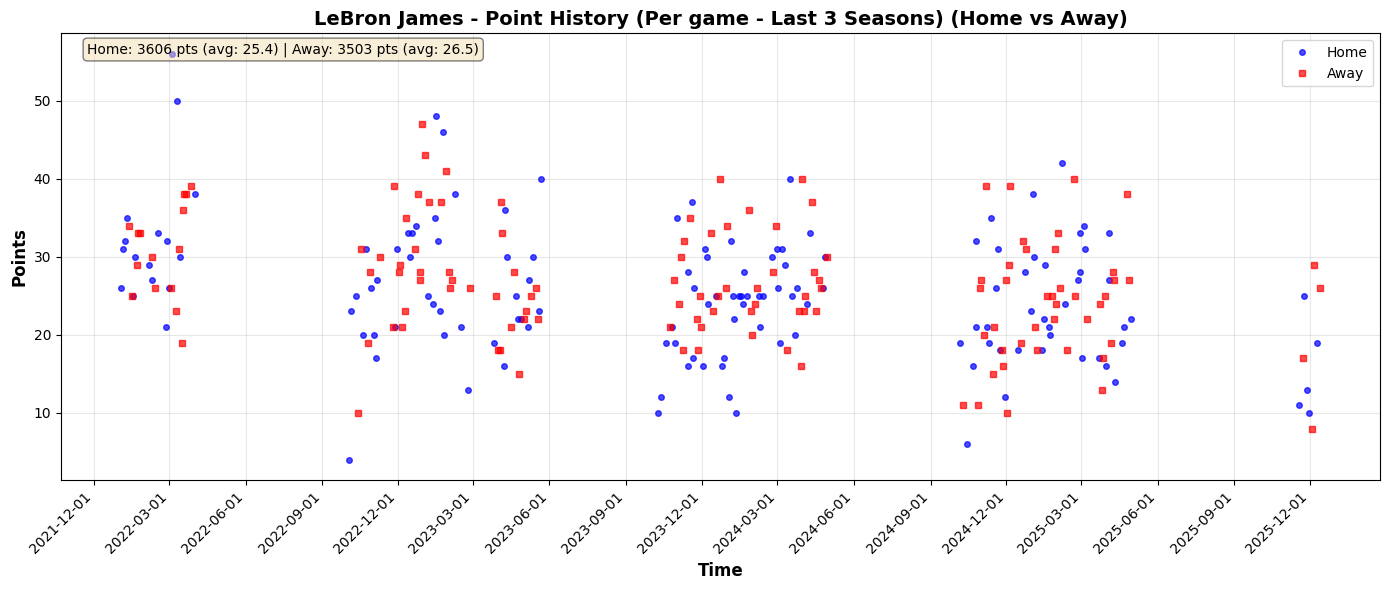

Examples ready to use - uncomment any line above to generate a graph


In [12]:
# Example 1: Show both home and away games
get_player_point_history("LeBron James", 3, games_per_point=1, show_home=True, show_away=True)

# Example 2: Show only home games
# get_player_point_history("LeBron James", 3, games_per_point=1, show_home=True, show_away=False)

# Example 3: Show only away games
# get_player_point_history("Stephen Curry", 1, games_per_point=1, show_home=True, show_away=True)

# Example 4: Sum of 5 games, home only
# get_player_point_history("Kevin Durant", 5, games_per_point=5, show_home=True, show_away=False)

# Example 5: Sum of 10 games, away only
# get_player_point_history("LeBron James", 10, games_per_point=10, show_home=False, show_away=True)

# Uncomment any example above to run it
print("Examples ready to use - uncomment any line above to generate a graph")

## 8. Team Point History Visualization

Function to visualize a team's scoring history over time with different granularity levels.

In [20]:
def get_team_point_history(team, numPastSeasons, games_per_point=1, show_home=True, show_away=True):
    """
    Generate a graph of team's scoring history over the specified number of past seasons.
    
    Parameters:
    -----------
    team : str
        Team name or abbreviation to search for (e.g., "Lakers", "LAL")
    numPastSeasons : int
        Number of past seasons to include in the analysis
    games_per_point : int
        Number of games to aggregate per data point (default: 1)
        - 1 = each point represents a single game
        - 2 = each point represents sum of 2 consecutive games
        - 5 = each point represents sum of 5 consecutive games
        etc.
    show_home : bool
        If True, show home games on the graph (default: True)
    show_away : bool
        If True, show away games on the graph (default: True)
    
    Returns:
    --------
    matplotlib figure showing the point history
    """
    
    if not show_home and not show_away:
        print("Error: At least one of show_home or show_away must be True")
        return None
    
    # Search for team in team_histories_df
    # Order by seasonActiveTill descending to prioritize currently active teams (null means active)
    matching_teams = team_histories_df.filter(
        (col("teamName").like(f"%{team}%")) | 
        (col("teamAbbrev").like(f"%{team}%")) |
        (col("teamCity").like(f"%{team}%"))
    ).orderBy(col("seasonActiveTill").desc_nulls_first())
    
    team_info = matching_teams.first()
    
    if not team_info:
        print(f"Team '{team}' not found in database.")
        return None
    
    team_id = team_info["teamId"]
    team_name = f"{team_info['teamCity']} {team_info['teamName']}"
    
    print(f"Found team: {team_name} (ID: {team_id})")
    
    # Calculate the cutoff date for seasons
    current_year = datetime.now().year
    cutoff_year = current_year - numPastSeasons
    
    # Filter team statistics
    team_games = team_stats_df.filter(col("teamId") == team_id) \
        .select(
            "gameDate", 
            "teamScore", 
            "home"
        )
    
    # Rename teamScore to points for consistency with player function
    team_games = team_games.withColumnRenamed("teamScore", "points")
    
    # Convert gameDate to date type if it's a string
    team_games = team_games.withColumn("gameDate", to_date(col("gameDate")))
    
    # Filter by date (last numPastSeasons years)
    cutoff_date = datetime(cutoff_year, 1, 1)
    team_games = team_games.filter(col("gameDate") >= cutoff_date)
    
    # Filter out null points
    team_games = team_games.filter(col("points").isNotNull())
    
    # Order by date
    team_games = team_games.orderBy("gameDate")
    
    # Separate home and away games (home is stored as int: 1 for home, 0 for away)
    home_games = team_games.filter(col("home") == 1).orderBy("gameDate") if show_home else None
    away_games = team_games.filter(col("home") == 0).orderBy("gameDate") if show_away else None
    
    # Convert to Pandas for easier manipulation
    home_df = home_games.toPandas() if home_games is not None else None
    away_df = away_games.toPandas() if away_games is not None else None
    
    if (home_df is None or home_df.empty) and (away_df is None or away_df.empty):
        print(f"No data found for {team_name} in the last {numPastSeasons} seasons.")
        return None
    
    # Aggregate by games_per_point
    def aggregate_games(df, games_per_point):
        if df is None or df.empty:
            return df
        
        # Create groups of n games
        df['game_group'] = df.index // games_per_point
        
        # Aggregate points and use the last date in each group
        aggregated = df.groupby('game_group').agg({
            'points': 'sum',
            'gameDate': 'last'
        }).reset_index()
        
        return aggregated
    
    home_agg = aggregate_games(home_df, games_per_point) if home_df is not None else None
    away_agg = aggregate_games(away_df, games_per_point) if away_df is not None else None
    
    # Print stats
    home_count = len(home_agg) if home_agg is not None and not home_agg.empty else 0
    away_count = len(away_agg) if away_agg is not None and not away_agg.empty else 0
    
    if show_home and show_away:
        print(f"Found {home_count} home and {away_count} away data points for {team_name}")
    elif show_home:
        print(f"Found {home_count} home data points for {team_name}")
    else:
        print(f"Found {away_count} away data points for {team_name}")
    print(f"(Aggregated by {games_per_point} game(s) per point)")
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot home games if requested
    if show_home and home_agg is not None and not home_agg.empty:
        ax.plot(home_agg['gameDate'], home_agg['points'], 
               marker='o', markersize=4, linestyle='', alpha=0.7, 
               label='Home', color='green')
    
    # Plot away games if requested
    if show_away and away_agg is not None and not away_agg.empty:
        ax.plot(away_agg['gameDate'], away_agg['points'], 
               marker='s', markersize=4, linestyle='', alpha=0.7, 
               label='Away', color='orange')
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')
    
    # Add statistics
    total_home = home_agg['points'].sum() if home_agg is not None and not home_agg.empty else 0
    total_away = away_agg['points'].sum() if away_agg is not None and not away_agg.empty else 0
    avg_home = home_agg['points'].mean() if home_agg is not None and not home_agg.empty else 0
    avg_away = away_agg['points'].mean() if away_agg is not None and not away_agg.empty else 0
    
    # Build stats text based on what's shown
    if show_home and show_away:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f}) | Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    elif show_home:
        stats_text = f'Home: {total_home:.0f} pts (avg: {avg_home:.1f})'
    else:
        stats_text = f'Away: {total_away:.0f} pts (avg: {avg_away:.1f})'
    
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Only show legend if both home and away are displayed
    if show_home and show_away:
        ax.legend(loc='upper right')
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Points', fontsize=12, fontweight='bold')
    
    game_label = "game" if games_per_point == 1 else f"{games_per_point} games"
    
    # Build title suffix
    if show_home and show_away:
        title_suffix = " (Home vs Away)"
    elif show_home:
        title_suffix = " (Home Only)"
    else:
        title_suffix = " (Away Only)"
    
    ax.set_title(f'{team_name} - Point History (Per {game_label} - Last {numPastSeasons} Seasons){title_suffix}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

print("Function 'get_team_point_history' is now available!")

Function 'get_team_point_history' is now available!


### Example Usage - Team Point History

Here are some examples of how to use the `get_team_point_history` function:

Found team: Golden State Warriors (ID: 1610612744)
Found 143 home data points for Golden State Warriors
(Aggregated by 1 game(s) per point)


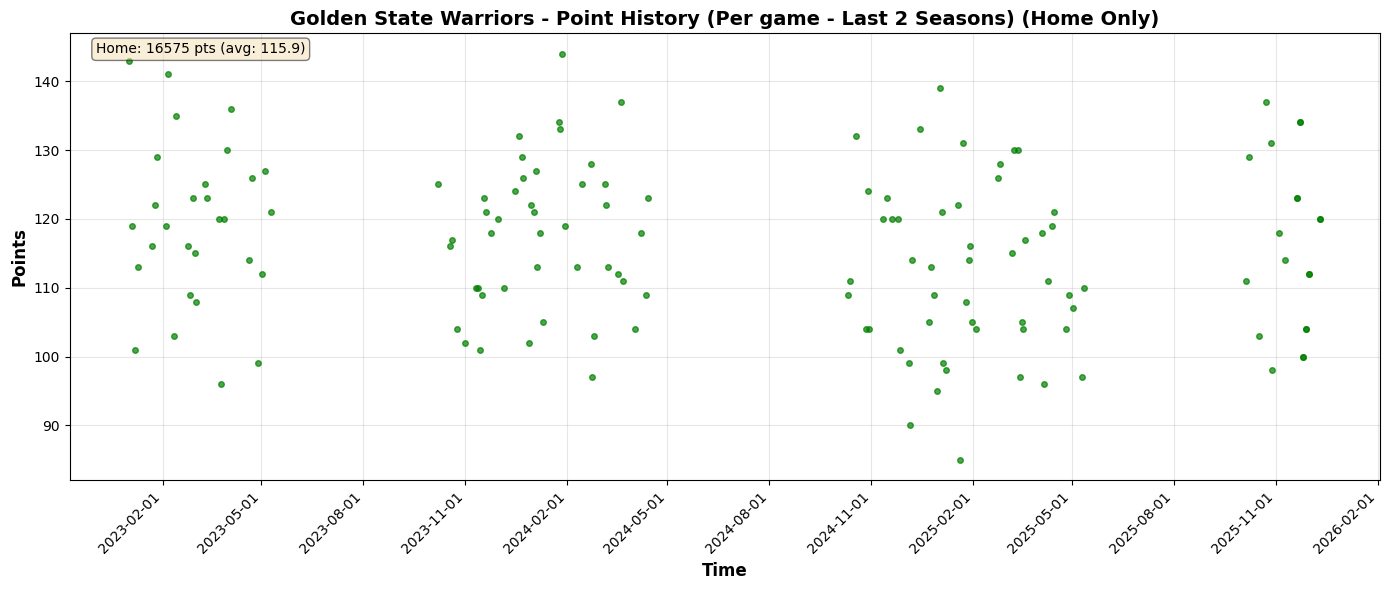

Team examples ready to use - uncomment any line above to generate a graph


25/12/15 17:41:39 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 316994 ms exceeds timeout 120000 ms
25/12/15 17:41:39 WARN SparkContext: Killing executors is not supported by current scheduler.
25/12/15 17:41:40 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:342)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [21]:
# Example 1: Show both home and away games for Lakers
# get_team_point_history("Lakers", 3, games_per_point=1, show_home=True, show_away=True)

# Example 2: Show only home games for Warriors
get_team_point_history("Warriors", 2, games_per_point=1, show_home=True, show_away=False)

# Example 3: Show only away games for Celtics
# get_team_point_history("Celtics", 1, games_per_point=1, show_home=False, show_away=True)

# Example 4: Sum of 5 games, home only for Bucks
# get_team_point_history("Bucks", 5, games_per_point=5, show_home=True, show_away=False)

# Example 5: Sum of 10 games for Heat
# get_team_point_history("Heat", 10, games_per_point=10, show_home=True, show_away=True)

# Uncomment any example above to run it
print("Team examples ready to use - uncomment any line above to generate a graph")